In [99]:

import os
import json
import re
from typing import Any, Dict, List, Optional, Union

import pandas as pd
import matplotlib.pyplot as plt

from lida import Manager, TextGenerationConfig
from llmx import llm

OLLAMA_BASE_URL = "http://localhost:11434/v1"   # Ollama OpenAI-compatible
OLLAMA_API_KEY = "ollama"                       # any string works for Ollama
MODEL_NAME = "gpt-oss:20b-cloud"                      # your model

# Text generation defaults (close to LIDA docs)
DEFAULT_N = 1
DEFAULT_TEMP_SUMMARY = 0.2
DEFAULT_TEMP_GOALS = 0.4
DEFAULT_TEMP_VIZ = 0.2
DEFAULT_TEMP_EDIT_EVAL = 0.0
USE_CACHE = True

LIBRARY = "seaborn"  # or "seaborn"

In [100]:

def flatten_json(obj: Dict[str, Any], parent: str = "", sep: str = "_") -> Dict[str, Any]:
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items

def load_jsonl(path: str, sample_rows: int = 5000) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))

    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip()
    return df

def load_csv(path_or_url: str) -> pd.DataFrame:
    return pd.read_csv(path_or_url)

In [101]:
import re

def pick_column_candidates(profile: dict, max_each: int = 200):
    # profile[col] = {"dtype": "...", "nunique": ..., "examples": [...], ...}
    cat, num, time = [], [], []

    def looks_like_time(col, meta):
        c = col.lower()
        if "time" in c or "date" in c or "timestamp" in c:
            return True
        # exemples qui ressemblent à date/iso
        ex = meta.get("examples", [])
        if not ex:
            return False
        s = " ".join(ex[:3])
        return bool(re.search(r"\d{4}-\d{2}-\d{2}|\d{2}:\d{2}:\d{2}", s))

    for col, meta in profile.items():
        dtype = (meta.get("dtype") or "").lower()
        nunique = meta.get("nunique", 0)
        miss = meta.get("missing_ratio", 0.0)

        # skip colonnes trop vides
        if miss is not None and miss > 0.95:
            continue

        # time candidates
        if looks_like_time(col, meta):
            time.append(col)
            continue

        # numeric candidates: on se base sur présence de min/max/mean ajoutés dans quick_profile()
        if "min" in meta and "max" in meta:
            num.append(col)
            continue

        # categorical candidates: peu de uniques
        if nunique and nunique <= 100:
            cat.append(col)

    return cat[:max_each], num[:max_each], time[:max_each]

In [102]:
import json
from typing import Any, Dict, List
import pandas as pd

def flatten_json(obj: Dict[str, Any], parent: str = "", sep: str = "_") -> Dict[str, Any]:
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items

def load_jsonl(path: str, sample_rows: int = 5000) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))
    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip()
    return df

df = load_jsonl("data/lidata.log", sample_rows=5000)

In [103]:
import json
import pandas as pd

def sanitize_nested_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        s = out[c].dropna()
        if s.empty:
            continue
        sample = s.head(50)
        if sample.apply(lambda v: isinstance(v, (list, dict))).any():
            out[c] = out[c].apply(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v)
    return out

df = sanitize_nested_cols(df)

In [104]:
import pandas as pd

def quick_profile(df: pd.DataFrame, max_cols: int = 40):
    cols = list(df.columns)[:max_cols]
    profile = {}
    for c in cols:
        s = df[c]
        profile[c] = {
            "dtype": str(s.dtype),
            "missing_ratio": float(s.isna().mean()),
            "nunique": int(s.nunique(dropna=True)),
        }
        ex = s.dropna().astype(str).head(5).tolist()
        profile[c]["examples"] = ex

        sn = pd.to_numeric(s, errors="coerce")
        if sn.notna().sum() > 0:
            profile[c]["min"] = float(sn.min())
            profile[c]["max"] = float(sn.max())
            profile[c]["mean"] = float(sn.mean())

    return profile

profile = quick_profile(df, max_cols=1502)

In [105]:
import re

def pick_column_candidates(profile: dict, max_each: int = 200):
    cat, num, time = [], [], []

    def looks_like_time(col, meta):
        c = col.lower()
        if "time" in c or "date" in c or "timestamp" in c:
            return True
        ex = meta.get("examples", [])
        if not ex:
            return False
        s = " ".join(ex[:3])
        return bool(re.search(r"\d{4}-\d{2}-\d{2}|\d{2}:\d{2}:\d{2}", s))

    for col, meta in profile.items():
        nunique = meta.get("nunique", 0)
        miss = meta.get("missing_ratio", 0.0)

        if miss is not None and miss > 0.95:
            continue

        if looks_like_time(col, meta):
            time.append(col)
            continue

        if "min" in meta and "max" in meta:
            num.append(col)
            continue

        if nunique and nunique <= 100:
            cat.append(col)

    return cat[:max_each], num[:max_each], time[:max_each]

In [106]:
import requests, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import traceback

def ollama_chat(model: str, system: str, user: str, temperature: float = 0.0) -> str:
    r = requests.post("http://localhost:11434/v1/chat/completions", json={
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        "temperature": temperature,
    })
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def extract_python_code(txt: str) -> str:
    m = re.search(r"```python(.*?)```", txt, flags=re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()
    m = re.search(r"```(.*?)```", txt, flags=re.DOTALL)
    if m:
        return m.group(1).strip()
    return txt.strip()

def strip_import_lines(code: str) -> str:
    lines = []
    for line in code.splitlines():
        if re.match(r"^\s*(import|from)\s+\w+", line):
            continue
        lines.append(line)
    return "\n".join(lines)

SYSTEM = """You are a data visualization code generator.
Return ONLY Python code (no explanations, no markdown, no backticks).
DO NOT write any import statements.
Use pandas DataFrame `df` already loaded.
Use seaborn as sns and matplotlib.pyplot as plt (already available).
Always call plt.tight_layout() and end with plt.show().

Rules:
- If user asks for count by category -> use groupby().size() or value_counts().
- For distribution of categories -> use seaborn countplot.
- For relationship between two numeric -> seaborn scatterplot.
- For trend over time -> lineplot and sort by x first.
"""

In [ ]:
def generate_and_run_viz(question: str, model: str):
    cat_cols, num_cols, time_cols = pick_column_candidates(profile, max_each=25)

    user = f"""
DATA PROFILE (schema + examples):
{profile}

CANDIDATE COLUMNS (auto-detected):
- categorical_cols: {cat_cols}
- numeric_cols: {num_cols}
- time_cols: {time_cols}

USER QUESTION:
{question}

Rules:
- Use ONLY existing columns from the profile keys.
- If the question implies a time trend, choose x from time_cols (or a numeric time-like column) and y from numeric_cols.
- If the question implies a distribution of categories, choose x from categorical_cols.
- If the question implies grouping ("by", "par"), choose group_by from categorical_cols and aggregate a numeric column if asked (mean/sum/min/max), otherwise count.
- Produce a single clear chart.
""".strip()

    raw = ollama_chat(model=model, system=SYSTEM, user=user, temperature=0.0)
    code = extract_python_code(raw)
    code = strip_import_lines(code)

    print("=== code génére (premiers 1500 characteres) ===")
    print(code[:1500])
    print("========================================")

    safe_builtins = {
        "len": len, "range": range, "min": min, "max": max, "sum": sum,
        "print": print, "sorted": sorted, "list": list, "dict": dict, "set": set,
        "enumerate": enumerate, "zip": zip, "abs": abs
    }
    safe_globals = {
        "__builtins__": safe_builtins,
        "pd": pd, "sns": sns, "plt": plt, "df": df
    }

    try:
        exec(code, safe_globals, {})
    except Exception:
        print("\n=== EXEC ERROR TRACEBACK ===")
        traceback.print_exc()
        print("=== END TRACEBACK ===")

    return code

In [108]:
MODEL_NAME = "gpt-oss:20b-cloud"

=== GENERATED CODE (first 1500 chars) ===
counts = df['ForceIdentifier'].value_counts()
fig, ax = plt.subplots(figsize=(6,6))
counts.plot.pie(ax=ax, labels=counts.index, colors=['red','blue'], autopct='%1.1f%%', startangle=90)
ax.set_ylabel('')
ax.set_title('Répartition des forces par camp')
plt.tight_layout()
plt.show()


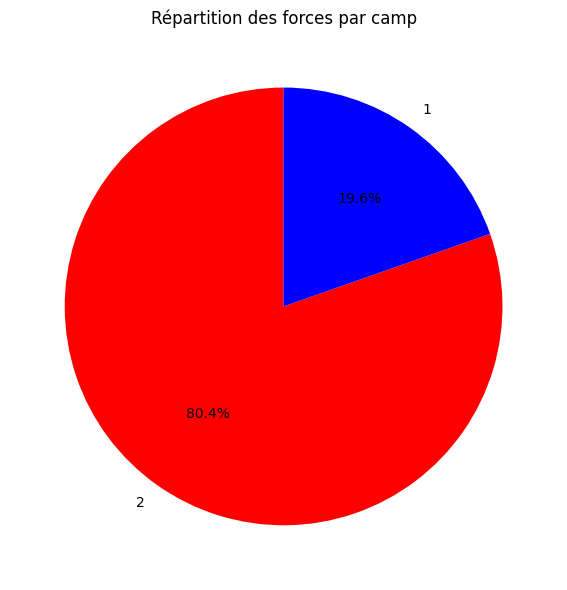

"counts = df['ForceIdentifier'].value_counts()\nfig, ax = plt.subplots(figsize=(6,6))\ncounts.plot.pie(ax=ax, labels=counts.index, colors=['red','blue'], autopct='%1.1f%%', startangle=90)\nax.set_ylabel('')\nax.set_title('Répartition des forces par camp')\nplt.tight_layout()\nplt.show()"

In [109]:
generate_and_run_viz(
    "Fais un pie chart de la répartition des forces par camp avec des coulerus roug et ver",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===

# Filter rows where the RVB is frozen
df_frozen = df[df['Spatial_RVB_IsFrozen']]

# Count how many frozen instances per entity
entity_counts = df_frozen['EntityIdentifier'].value_counts().sort_index()

# Plot distribution of frozen entities
plt.figure(figsize=(10, 6))
sns.barplot(x=entity_counts.index, y=entity_counts.values, palette='viridis')
plt.xlabel('Entity Identifier')
plt.ylabel('Count of Frozen RVB')
plt.title('Entities with Frozen RVB')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<string>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



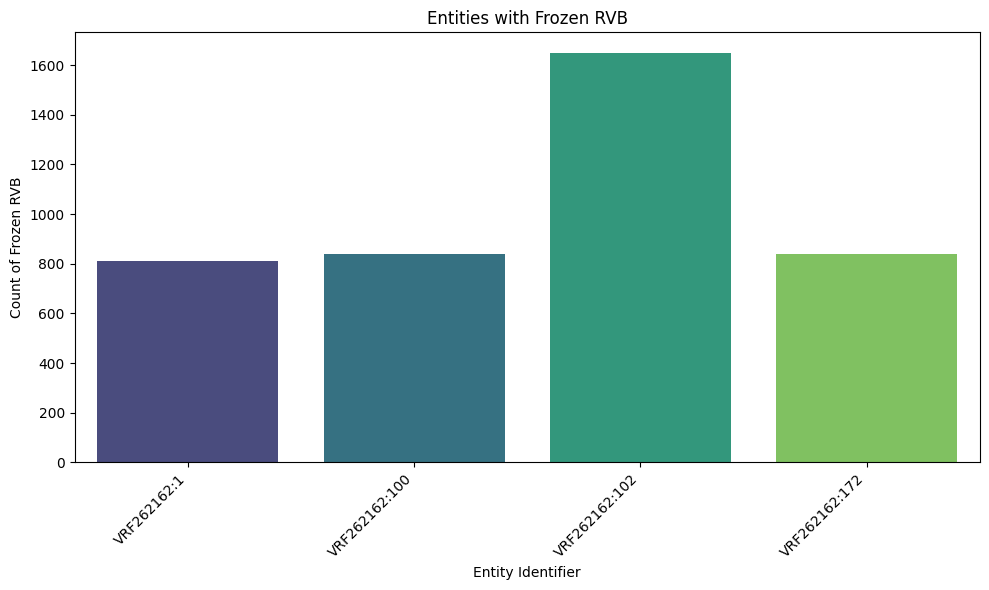

"\n# Filter rows where the RVB is frozen\ndf_frozen = df[df['Spatial_RVB_IsFrozen']]\n\n# Count how many frozen instances per entity\nentity_counts = df_frozen['EntityIdentifier'].value_counts().sort_index()\n\n# Plot distribution of frozen entities\nplt.figure(figsize=(10, 6))\nsns.barplot(x=entity_counts.index, y=entity_counts.values, palette='viridis')\nplt.xlabel('Entity Identifier')\nplt.ylabel('Count of Frozen RVB')\nplt.title('Entities with Frozen RVB')\nplt.xticks(rotation=45, ha='right')\nplt.tight_layout()\nplt.show()"

In [110]:

# Test
generate_and_run_viz(
    "Quelles entités ont le RVB gelé ? tu ferasi les ",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
plt.figure(figsize=(8,6))
sns.countplot(x='ForceIdentifier', data=df)
plt.title('Nombre d’entités par Force')
plt.xlabel('ForceIdentifier')
plt.ylabel('Nombre d’entités')
plt.tight_layout()
plt.show()


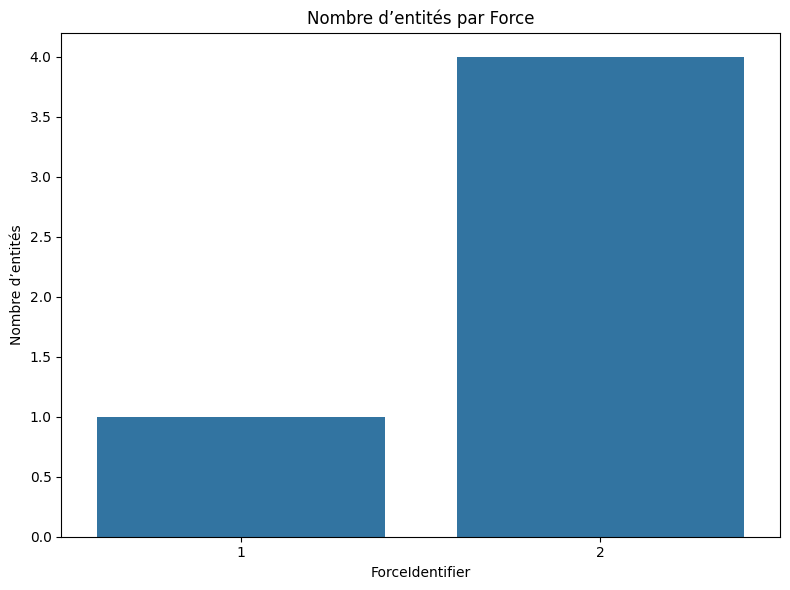

"plt.figure(figsize=(8,6))\nsns.countplot(x='ForceIdentifier', data=df)\nplt.title('Nombre d’entités par Force')\nplt.xlabel('ForceIdentifier')\nplt.ylabel('Nombre d’entités')\nplt.tight_layout()\nplt.show()"

In [98]:

# Test
generate_and_run_viz(
    "Quel camp est le plus nombreux ",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
median_by_type = df.groupby('EntityType')['SimTime'].median().reset_index()
median_by_type.rename(columns={'SimTime':'MedianSimTime'}, inplace=True)
plt.figure(figsize=(10,6))
sns.barplot(x='EntityType', y='MedianSimTime', data=median_by_type)
plt.xlabel('Type d\'entité')
plt.ylabel('Médiane du temps (SimTime)')
plt.title('Médiane du temps par type d\'entité')
plt.tight_layout()
plt.show()


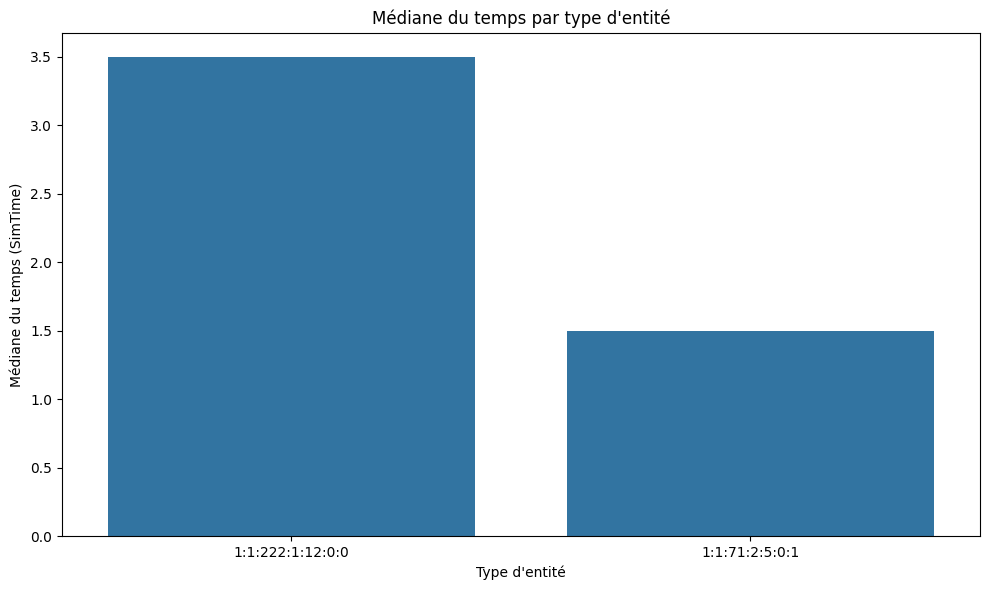

"median_by_type = df.groupby('EntityType')['SimTime'].median().reset_index()\nmedian_by_type.rename(columns={'SimTime':'MedianSimTime'}, inplace=True)\nplt.figure(figsize=(10,6))\nsns.barplot(x='EntityType', y='MedianSimTime', data=median_by_type)\nplt.xlabel('Type d\\'entité')\nplt.ylabel('Médiane du temps (SimTime)')\nplt.title('Médiane du temps par type d\\'entité')\nplt.tight_layout()\nplt.show()"

In [111]:
generate_and_run_viz(
    "Médiane du temps de chaque type d'entité",
    model=MODEL_NAME
)

In [ ]:
#48464

In [68]:
import pandas as pd

def quick_profile(df: pd.DataFrame, max_cols: int = 40):
    # top colonnes utiles: catégorielles + numériques
    cols = list(df.columns)
    

    profile = {}
    for c in cols:
        s = df[c]
        profile[c] = {
            "dtype": str(s.dtype),
            "missing_ratio": float(s.isna().mean()),
            "nunique": int(s.nunique(dropna=True)),
        }
        # exemples de valeurs
        ex = s.dropna().astype(str).head(5).tolist()
        profile[c]["examples"] = ex

        # stats num
        sn = pd.to_numeric(s, errors="coerce")
        if sn.notna().sum() > 0:
            profile[c]["min"] = float(sn.min())
            profile[c]["max"] = float(sn.max())
            profile[c]["mean"] = float(sn.mean())

    return profile

profile = quick_profile(df, max_cols=500) # tu peux baisser si c'est trop long
print("profile keys:", list(profile.keys())[:10])

TypeError: unhashable type: 'list'

In [12]:
import requests, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import traceback

def ollama_chat(model: str, system: str, user: str, temperature: float = 0.0) -> str:
    r = requests.post("http://localhost:11434/v1/chat/completions", json={
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        "temperature": temperature,
    })
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def extract_python_code(txt: str) -> str:
    m = re.search(r"```python(.*?)```", txt, flags=re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()
    m = re.search(r"```(.*?)```", txt, flags=re.DOTALL)
    if m:
        return m.group(1).strip()
    return txt.strip()

def strip_import_lines(code: str) -> str:
    # enlève les lignes "import ..." et "from ... import ..."
    lines = []
    for line in code.splitlines():
        if re.match(r"^\s*(import|from)\s+\w+", line):
            continue
        lines.append(line)
    return "\n".join(lines)

SYSTEM = """You are a data visualization code generator.
Return ONLY Python code (no explanations, no markdown, no backticks).
DO NOT write any import statements.
Use pandas DataFrame `df` already loaded.
Use seaborn as sns and matplotlib.pyplot as plt (already available).
Always call plt.tight_layout() and end with plt.show().

Rules:
- If user asks for count by category -> use groupby().size() or value_counts().
- For distribution of categories -> use seaborn countplot.
- For relationship between two numeric -> seaborn scatterplot.
- For trend over time -> lineplot and sort by x first.
"""

def generate_and_run_viz(question: str, model: str):
    cat_cols, num_cols, time_cols = pick_column_candidates(profile, max_each=25)

    user = f"""
    DATA PROFILE (schema + examples):
    {profile}

    CANDIDATE COLUMNS (auto-detected):
    - categorical_cols: {cat_cols}
    - numeric_cols: {num_cols}
    - time_cols: {time_cols}

    USER QUESTION:
    {question}

    Rules:
    - Use ONLY existing columns from the profile keys.
    - If the question implies a time trend, choose x from time_cols (or a numeric time-like column) and y from numeric_cols.
    - If the question implies a distribution of categories, choose x from categorical_cols.
    - If the question implies grouping ("by", "par"), choose group_by from categorical_cols and aggregate a numeric column if asked (mean/sum/min/max), otherwise count.
    - Produce a single clear chart.
    """.strip()
    
    raw = ollama_chat(model=model, system=SYSTEM, user=user, temperature=0.0)
    code = extract_python_code(raw)
    code = strip_import_lines(code)  # sécurité si le modèle met quand même des imports

    print("=== GENERATED CODE (first 1500 chars) ===")
    print(code[:1500])
    print("========================================")

    # Exec "semi-safe": autorise quelques builtins nécessaires
    safe_builtins = {
        "len": len, "range": range, "min": min, "max": max, "sum": sum,
        "print": print, "sorted": sorted, "list": list, "dict": dict, "set": set,
        "enumerate": enumerate, "zip": zip, "abs": abs
    }
    safe_globals = {
        "__builtins__": safe_builtins,
        "pd": pd, "sns": sns, "plt": plt, "df": df
    }

    try:
        exec(code, safe_globals, {})
    except Exception:
        print("\n=== EXEC ERROR TRACEBACK ===")
        traceback.print_exc()
        print("=== END TRACEBACK ===")


=== GENERATED CODE (first 1500 chars) ===
sns.scatterplot(x='Spatial_RVB_WorldLocation_x', y='Spatial_RVB_WorldLocation_y', data=df, color='green')
plt.tight_layout()
plt.show()


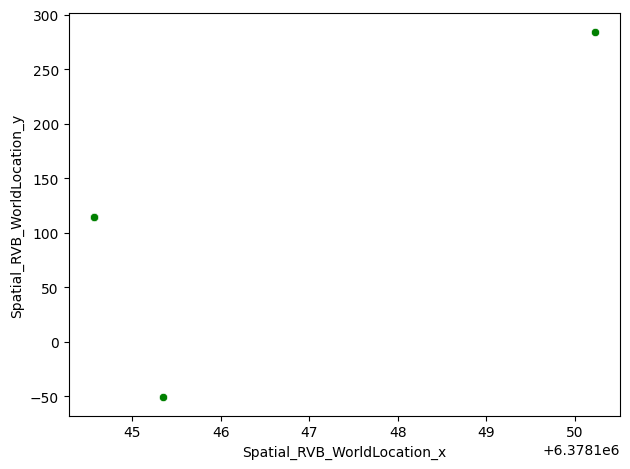

In [15]:
generate_and_run_viz(
    "Nuage de points des positions RVB y et RVB x avec des point vert feuille",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
# Group damages by ForceIdentifier
damage_counts = (
    df
    .groupby('ForceIdentifier')
    ['DamageState']
    .apply(lambda x: (x == 'damaged').sum())
    .reset_index(name='DamagedCount')
)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(
    data=damage_counts,
    x='ForceIdentifier',
    y='DamagedCount',
    palette='viridis'
)
plt.title('Number of Damaged Entities per Force Identifier')
plt.xlabel('Force Identifier')
plt.ylabel('Count of Damaged')
plt.tight_layout()
plt.show()


<string>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



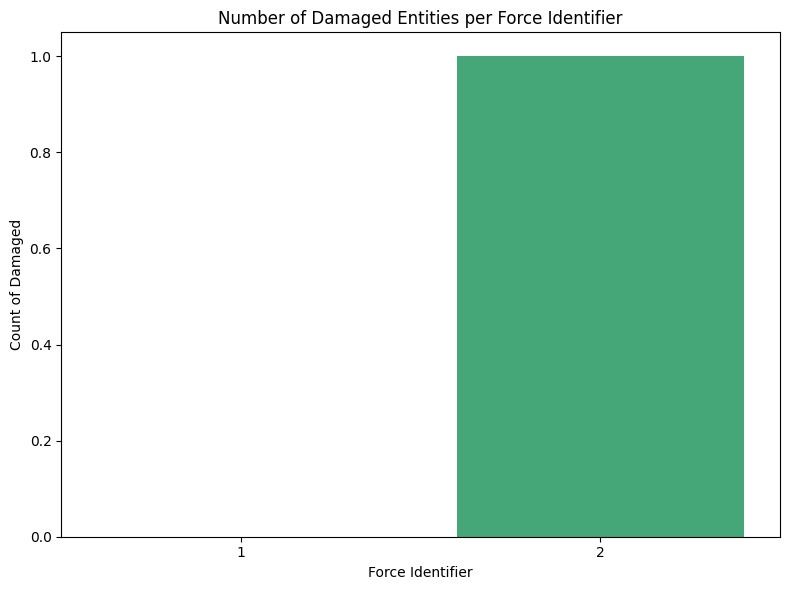

In [8]:

# Test
generate_and_run_viz(
    " Dégats groupé par identifiant de forces ",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
sns.countplot(x='EntityIdentifier', data=df[df['Spatial_RVB_IsFrozen']])
plt.title('Entities with Spatial_RVB_IsFrozen = True')
plt.xlabel('EntityIdentifier')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


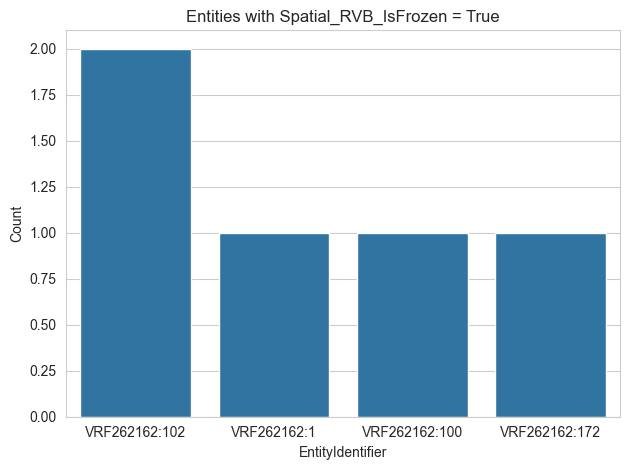

In [ ]:

# Test
generate_and_run_viz(
    "Quelles entités ont le RVB gelé ? tu ferasi les ",
    model=MODEL_NAME
)

=== GENERATED CODE (first 1500 chars) ===
labels = df['ForceIdentifier'].value_counts().index
sizes = df['ForceIdentifier'].value_counts().values
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Répartition des forces par camp')
plt.tight_layout()
plt.show()


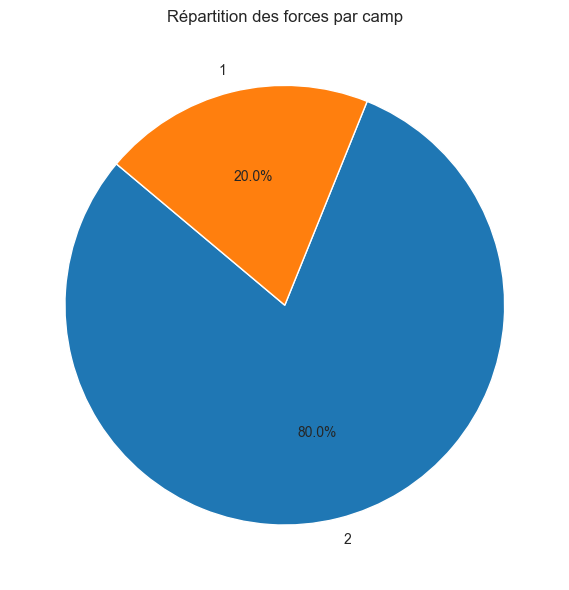

In [18]:
generate_and_run_viz(
    "Fais un pie chart de la répartition des forces par camp",
    model=MODEL_NAME
)